# ZINC Streaming Training and Sampling

This notebook trains a Conditional Node Field generator directly from the ZINC CSV through the streaming path, saves periodic snapshots, and compares filtered and unfiltered molecule samples.

This notebook showcases the schema-frozen streaming training path for `ConditionalNodeFieldGraphGenerator`.

- source: raw ZINC CSV
- warmup: first 1000 accepted graphs
- stream limit: `0.1`
- targets: none
- final cells: generate 7 graphs without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import os
import random

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecules
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


PyTorch version: 2.5.0+cpu
CUDA available: False


In [2]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc18'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
STREAM_LIMIT = 0.9
WARMUP_SIZE = 2049
STREAM_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 256
EMBEDDING_DIM = 64
VERBOSE = 2
MODEL_NAME = f'{ZINC_SIZE}-streaming-d{EMBEDDING_DIM}-s{STREAM_LIMIT}-w{WARMUP_SIZE}-b{STREAM_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
DECODER_N_JOBS = 1
STREAM_SNAPSHOT_EVERY_N_BATCHES = 20
URI = ZINC_DATA_ROOT / ZINC_FILENAME
RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=2,
    transformer_attention_head_count=4,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=STREAM_BATCH_SIZE,
    verbose=VERBOSE,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
    stream_snapshot_every_n_batches=STREAM_SNAPSHOT_EVERY_N_BATCHES,
)
graph_generator.stream_batch_timeout_seconds = None
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules


Configured graph generator model_name=zinc18-streaming-d64-s0-9-w2049-b128-e256 model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [4]:


graph_generator.fit_from_stream(
    URI,
    "zinc_csv",
    warmup_size=WARMUP_SIZE,
    batch_size=STREAM_BATCH_SIZE,
    limit=STREAM_LIMIT,
    random_state=RANDOM_SEED,
    verbose=VERBOSE,
)

print('stream_seen_ =', graph_generator.stream_seen_)
print('stream_warmup_count_ =', graph_generator.stream_warmup_count_)
print('stream_training_seen_ =', graph_generator.stream_training_seen_)
print('stream_training_accepted_ =', graph_generator.stream_training_accepted_)
print('stream_training_skipped_ =', graph_generator.stream_training_skipped_)
print('stream_acceptance_rate_ =', graph_generator.stream_acceptance_rate_)


Streaming batch timeout is disabled; using the safe default 30.0s for this fit so stalled batch-preparation steps are skipped instead of blocking indefinitely.
Streaming Bernoulli quota: limit=0.900, source_count=75344, selected_per_epoch=67810.
Warmup fitting on 2049 streamed graphs.
Fitting feasibility estimator on 2049 graphs
Finished fitting feasibility estimator in 0m 40.5s
Supervision plan:
  node_labels: mode=learned, enabled. 8 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 206916 pairs (50.00%) from 413832 total pairs (pos=137972, neg=275860, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon

In [5]:
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
list_saved_graph_generators(SAVED_GENERATOR_ROOT)

,name,modified,size_mb
0,zinc20-nonstreaming-d64-s0-99-b128-e350.pkl,2026-04-02 16:59,1087.9
1,zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl,2026-04-02 14:27,36.1
2,zinc15-nonstreaming-d64-s0-99-b128-e350.pkl,2026-04-02 14:27,176.1
3,zinc15-streaming-d64-s0-5-w256-b8-e256.pkl,2026-04-02 04:54,8.1
4,artificial-d32-n86-size8.pkl,2026-03-24 19:40,4.4


['zinc20-nonstreaming-d64-s0-99-b128-e350.pkl',
 'zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl',
 'zinc15-nonstreaming-d64-s0-99-b128-e350.pkl',
 'zinc15-streaming-d64-s0-5-w256-b8-e256.pkl',
 'artificial-d32-n86-size8.pkl']

In [6]:
# Resume later with a copied filename from the save cell. 
if False:
    MODEL_FILENAME = 'zinc-d64-n10000-size10-18.pkl'  # Replace with your chosen filename from the list above.
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)

Sampling 7 graphs
Streaming ZINC samples without feasibility filtering


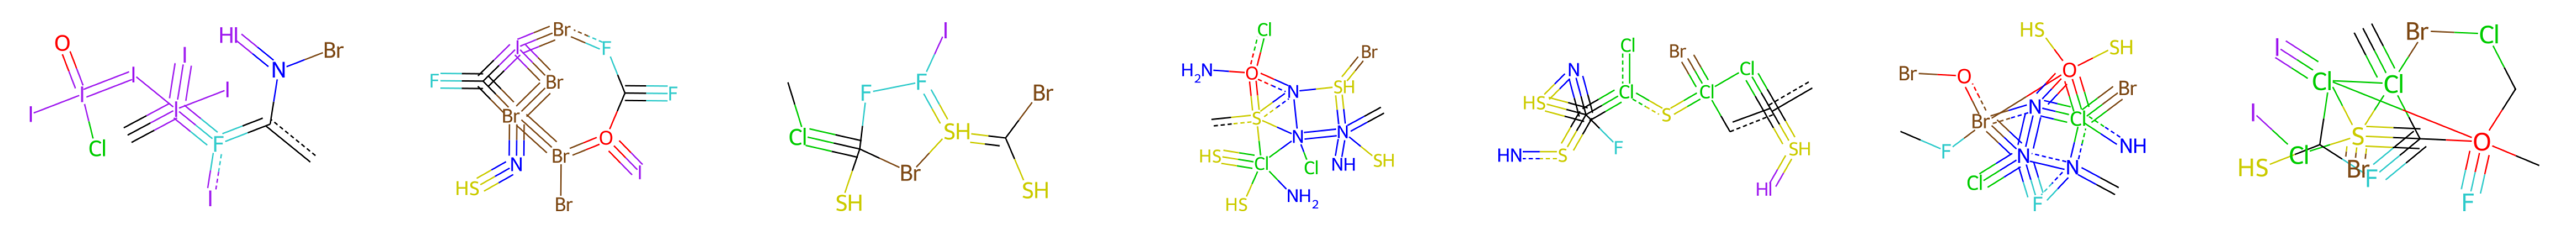

In [7]:
raw_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=False,
)
show_molecules(raw_samples, n=7, title='Streaming ZINC samples without feasibility filtering')


Sampling 7 graphs
Oracle initial adjacency decode failed under connectivity constraints; retrying with connectivity disabled for the seed solve.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=9m 58.1s | eta=3h 09m 23.3s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=8m 53.7s | eta=2h 49m 46.0s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 09.5s | eta=1h 53m 27.5s
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 16.4s | eta=1h 25m 10.9s
Feasibility attempt  5/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 24.0s | eta=1h 08m 05.3s
Feasibility attempt  6/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 17.2s | eta=55m 57.6s
Feasibility attempt  7/20 | generated=   8 | feasible_

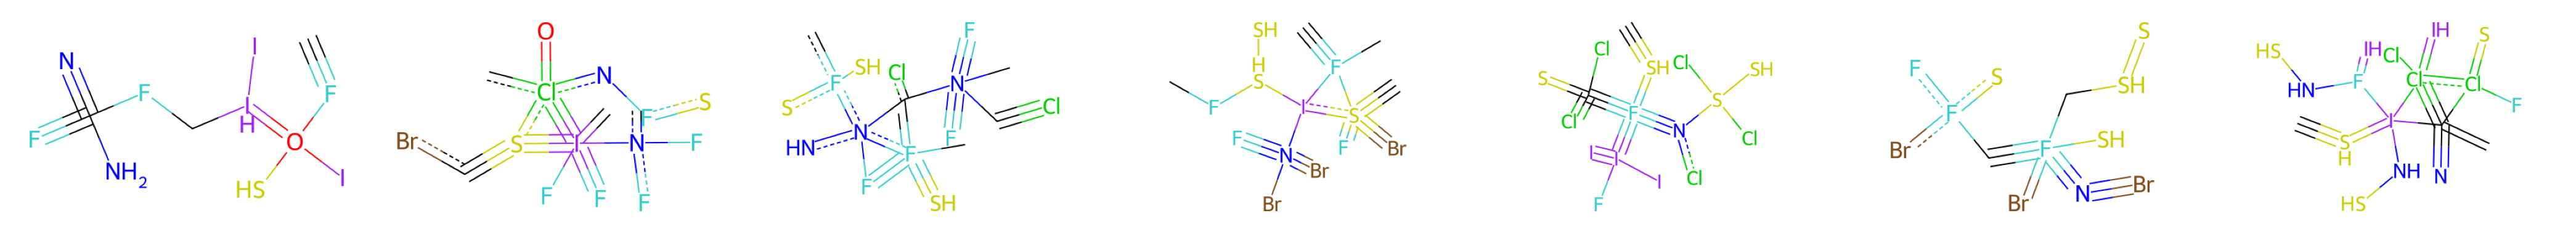

In [8]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=7, title='Streaming ZINC samples with feasibility filtering')
